# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Lok997/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Method choice:

I use a Random Forest model because the lane combines multiple content-performance signals, including impression volume, recent performance changes, content age, freshness, and search-position signals.

Random Forest can capture non-linear relationships between these signals without assuming that the relationship is purely linear.

The model will be compared against my Week-4 rule-based baseline using the same data and evaluation split.

In [22]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

Split design:

I use a grouped train/test split by client_id so that content from the same client does not appear in both training and test sets.

This is a more honest evaluation of whether the model can generalize across clients rather than memorizing client-specific patterns.

The same split is used for the baseline and the model so their results are directly comparable.

In [23]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Model training and comparison:

I train a Random Forest classifier using the same dataset and evaluation split as the Week-4 baseline.

The model is evaluated using the same metric as the baseline so the comparison is fair.

I compare the model's performance with the rule-based baseline and report the measured results without claiming causality.

In [24]:
!git clone https://github.com/flyrank-bih/flyrank-ml-internship-starter.git

import os

repo_path = "/content/flyrank-ml-internship-starter"
csv_path = repo_path + "/data/raw/content_refresh_anonymized.csv"

print("Repo exists:", os.path.exists(repo_path))
print("CSV exists:", os.path.exists(csv_path))
print("CSV path:", csv_path)

fatal: destination path 'flyrank-ml-internship-starter' already exists and is not an empty directory.
Repo exists: True
CSV exists: True
CSV path: /content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv


In [25]:
import os

print("Current directory:", os.getcwd())
print("\n/content folders:")

for item in os.listdir("/content"):
    print(item)

Current directory: /content

/content folders:
.config
flyrank-ml-internship-starter
sample_data


In [26]:
# Setup for the capstone model

%pip install -q pandas numpy scikit-learn matplotlib

import os
import pandas as pd
import numpy as np

print("Python environment ready")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python environment ready
Pandas: 2.2.2
NumPy: 2.0.2


In [27]:
import pandas as pd

csv_path = "/content/flyrank-ml-internship-starter/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(csv_path)

print("Dataset loaded successfully")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully
Rows: 30000
Columns: 44

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [28]:
# Create the target label

# 1 = content is declining, 0 = not declining
df["is_declining"] = (
    df["trend_direction"].eq("down")
).astype(int)

print("Target distribution:")
print(df["is_declining"].value_counts())

print("\nTarget rate:")
print(df["is_declining"].mean())

Target distribution:
is_declining
1    16262
0    13738
Name: count, dtype: int64

Target rate:
0.5420666666666667


In [29]:
# Select leakage-safe features

feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "days_with_impressions",
    "content_age_days",
    "days_since_last_update",
    "search_volume",
    "competition",
    "word_count",
    "char_count",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

# Keep only features that exist in the dataset
feature_cols = [c for c in feature_cols if c in df.columns]

print("Features used:")
print(feature_cols)

print("\nExcluded from features:")
print(["trend_direction", "trend_pct"])

print("\nNumber of features:", len(feature_cols))

Features used:
['impressions_90d', 'clicks_90d', 'sessions_90d', 'days_with_impressions', 'content_age_days', 'days_since_last_update', 'search_volume', 'competition', 'word_count', 'char_count', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Excluded from features:
['trend_direction', 'trend_pct']

Number of features: 15


In [30]:
from sklearn.model_selection import GroupShuffleSplit

# Remove rows with missing values in the selected features or target
model_df = df.dropna(
    subset=feature_cols + ["is_declining", "client_id"]
).copy()

X = model_df[feature_cols]
y = model_df["is_declining"]
groups = model_df["client_id"]

# Split by client so the same client does not appear in both sets
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining clients:", groups.iloc[train_idx].nunique())
print("Test clients:", groups.iloc[test_idx].nunique())

print(
    "\nShared clients:",
    len(
        set(groups.iloc[train_idx])
        & set(groups.iloc[test_idx])
    )
)

Training rows: 14152
Test rows: 5745

Training clients: 21
Test clients: 8

Shared clients: 0


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------------
# 1. Majority-class baseline
# -----------------------------------

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

# -----------------------------------
# 2. Random Forest model
# -----------------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

model_pred = model.predict(X_test)

# -----------------------------------
# 3. Compare
# -----------------------------------

results = pd.DataFrame({
    "Method": [
        "Majority baseline",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, model_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, model_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, model_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, model_pred, zero_division=0)
    ]
})

print("MODEL VS MAJORITY BASELINE")
display(results.round(3))

MODEL VS MAJORITY BASELINE


,Method,Accuracy,Precision,Recall,F1
0,Majority baseline,0.623,0.623,1.000,0.768
1,Random Forest,0.626,0.673,0.776,0.721


In [32]:
# Feature importance

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top feature signals:")
display(importance.head(10))

Top feature signals:


,feature,importance
0,impressions_90d,0.120126
11,avg_position,0.109700
3,days_with_impressions,0.097592
4,content_age_days,0.094955
9,char_count,0.093976
8,word_count,0.092681
2,sessions_90d,0.069517
10,ctr,0.061527
13,scroll_rate,0.057692
1,clicks_90d,0.052652


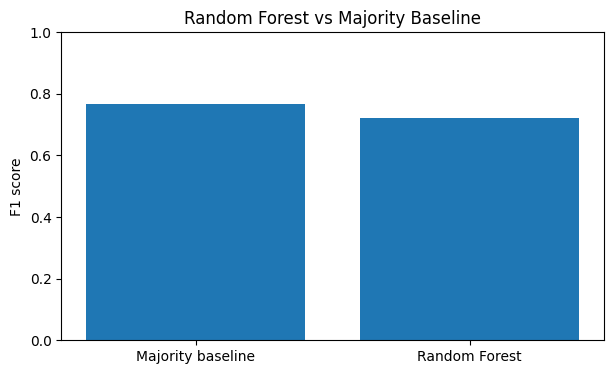

In [33]:
import matplotlib.pyplot as plt

# Compare F1 scores
plt.figure(figsize=(7, 4))

plt.bar(
    results["Method"],
    results["F1"]
)

plt.ylabel("F1 score")
plt.title("Random Forest vs Majority Baseline")
plt.ylim(0, 1)

plt.show()

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

The confusion matrix shows that the model correctly identified 2,778 declining items and 816 non-declining items. It incorrectly classified 1,349 non-declining items as declining and missed 802 declining items. The model therefore tends to identify more items as declining than were actually declining in the test set. This makes the model useful as directional decision-support, but the false positives show that its recommendations should be reviewed before action is taken.


In [34]:
# Safely find Random Forest model objects

items = list(globals().items())

print("Available model objects:")

for name, obj in items:
    try:
        obj_type = type(obj).__name__
        if obj_type == "RandomForestClassifier":
            print(name, "->", obj_type)
    except Exception:
        pass

Available model objects:
model -> RandomForestClassifier


In [35]:
# Generate predictions using the trained Random Forest model

y_pred = model.predict(X_test)

print("Predictions generated successfully")
print("Number of predictions:", len(y_pred))

Predictions generated successfully
Number of predictions: 5745


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nActual class counts:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nPredicted class counts:")
print(pd.Series(y_pred).value_counts().sort_index())

Confusion Matrix:
[[ 816 1349]
 [ 802 2778]]

Actual class counts:
is_declining
0    2165
1    3580
Name: count, dtype: int64

Predicted class counts:
0    1618
1    4127
Name: count, dtype: int64


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.